
# Anchored \(N\)-Lobed Lorenz Attractor

This notebook implements the anchored cylindrical-coordinate $N$-Lorenz system

$$
\phi = \frac{N}{2}\left(\theta-\frac{\pi}{4}\right)+\frac{\pi}{4},
$$

$$
\dot r =
r\left[
(\sigma+\rho-z)\sin\phi\cos\phi
-\sigma\cos^2\phi
-\sin^2\phi
\right],
$$

$$
\dot\theta =
\frac{2}{N}\left[
(\rho-z)\cos^2\phi
-\sigma\sin^2\phi
+(\sigma-1)\sin\phi\cos\phi
\right],
$$

$$
\dot z = r^2\sin\phi\cos\phi-\beta z.
$$

For $N=2$, this reduces exactly to the ordinary Lorenz system in cylindrical coordinates.

The nonzero fixed points are

$$
\theta_k = \frac{\pi}{4}+\frac{2\pi k}{N},
\qquad
r_k=r_L=\sqrt{2\beta(\rho-1)},
\qquad
z_k=\rho-1.
$$

Thus the $k=0$ fixed point always coincides with the positive fixed point of the original Lorenz system. With the standard parameters,

$$
r_L=12,
\qquad
P_+=(6\sqrt{2},6\sqrt{2},27).
$$

All lobes use the same radius in this version.



In [60]:

# If needed, uncomment the next line:
# %pip install numpy scipy matplotlib ipywidgets

import zipfile
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

import ipywidgets as widgets
from IPython.display import display, clear_output

SIGMA = 10.0
RHO   = 28.0
BETA  = 8.0 / 3.0

R_LORENZ = np.sqrt(2.0 * BETA * (RHO - 1.0))
Z_LORENZ = RHO - 1.0

print(f"Original Lorenz fixed-point radius r_L = {R_LORENZ:.6f}")
print(f"Original Lorenz fixed-point height z_L = {Z_LORENZ:.6f}")


Original Lorenz fixed-point radius r_L = 12.000000
Original Lorenz fixed-point height z_L = 27.000000



## Numerical model

The integration is performed directly in $(r,\theta,z)$, then converted to Cartesian coordinates using

$$
x=r\cos\theta,\qquad y=r\sin\theta.
$$

The initial-condition controls are specified in Cartesian coordinates.

The random initial-condition button samples uniformly from a box that comfortably contains the standard Lorenz attractor:

$$
x\in[-25,25],\qquad
y\in[-25,25],\qquad
z\in[0,55].
$$

The same seed always generates the same initial condition.



In [63]:

IC_X_RANGE = (-25.0, 25.0)
IC_Y_RANGE = (-25.0, 25.0)
IC_Z_RANGE = (0.0, 55.0)

def anchored_n_lorenz(t, state, N,
                      sigma=SIGMA, rho=RHO, beta=BETA):
    r, theta, z = state

    phi = 0.5 * N * (theta - np.pi / 4.0) + np.pi / 4.0

    sp = np.sin(phi)
    cp = np.cos(phi)

    dr = r * (
        (sigma + rho - z) * sp * cp
        - sigma * cp**2
        - sp**2
    )

    dtheta = (2.0 / N) * (
        (rho - z) * cp**2
        - sigma * sp**2
        + (sigma - 1.0) * sp * cp
    )

    dz = r**2 * sp * cp - beta * z

    return [dr, dtheta, dz]


def cartesian_to_cylindrical(x0, y0, z0):
    r0 = np.hypot(x0, y0)

    if r0 < 1.0e-10:
        r0 = 1.0e-10
        theta0 = 0.0
    else:
        theta0 = np.arctan2(y0, x0)

    return np.array([r0, theta0, z0], dtype=float)


def cylindrical_to_cartesian(r, theta):
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return x, y


def fixed_points(N):
    k = np.arange(N)
    theta_k = np.pi / 4.0 + 2.0 * np.pi * k / N
    xk = R_LORENZ * np.cos(theta_k)
    yk = R_LORENZ * np.sin(theta_k)
    zk = np.full(N, Z_LORENZ)
    return xk, yk, zk, theta_k


In [65]:

N_slider = widgets.IntSlider(
    value=3, min=2, max=50, step=1,
    description='N lobes:',
    continuous_update=False,
    style={'description_width': '90px'},
    layout=widgets.Layout(width='420px')
)

time_slider = widgets.IntSlider(
    value=200, min=5, max=1000, step=5,
    description='Time:',
    continuous_update=False,
    style={'description_width': '90px'},
    layout=widgets.Layout(width='420px')
)

seed_widget = widgets.IntText(
    value=1,
    description='Seed:',
    style={'description_width': '90px'},
    layout=widgets.Layout(width='210px')
)

x0_widget = widgets.FloatText(
    value=1.0, description='x0:',
    style={'description_width': '40px'},
    layout=widgets.Layout(width='180px')
)

y0_widget = widgets.FloatText(
    value=1.0, description='y0:',
    style={'description_width': '40px'},
    layout=widgets.Layout(width='180px')
)

z0_widget = widgets.FloatText(
    value=20.0, description='z0:',
    style={'description_width': '40px'},
    layout=widgets.Layout(width='180px')
)

random_button = widgets.Button(
    description='Random I.C. + Run',
    button_style='info'
)

run_button = widgets.Button(
    description='Run simulation',
    button_style='success'
)

save_button = widgets.Button(
    description='Save latest x,y,z vs time',
    button_style='warning'
)

output = widgets.Output()
status = widgets.Output()

latest_run = {'valid': False}


In [67]:

def simulate_current():
    N = int(N_slider.value)
    T = float(time_slider.value)

    x0 = float(x0_widget.value)
    y0 = float(y0_widget.value)
    z0 = float(z0_widget.value)

    state0 = cartesian_to_cylindrical(x0, y0, z0)

    dt_out = 0.1
    npts = int(np.floor(T / dt_out)) + 1
    t_eval = np.linspace(0.0, T, npts)

    sol = solve_ivp(
        anchored_n_lorenz,
        (0.0, T),
        state0,
        args=(N,),
        method='DOP853',
        t_eval=t_eval,
        rtol=1.0e-9,
        atol=1.0e-11,
        max_step=0.05
    )

    if not sol.success:
        raise RuntimeError(sol.message)

    r = sol.y[0]
    theta = sol.y[1]
    z = sol.y[2]
    x, y = cylindrical_to_cartesian(r, theta)
    t = sol.t

    latest_run.clear()
    latest_run.update({
        'valid': True,
        'N': N,
        'T': T,
        'seed': int(seed_widget.value),
        'x0': x0,
        'y0': y0,
        'z0': z0,
        't': t,
        'x': x,
        'y': y,
        'z': z,
        'r': r,
        'theta': theta
    })

    plot_latest_run()


def plot_latest_run():
    if not latest_run.get('valid', False):
        return

    N = latest_run['N']
    t = latest_run['t']
    x = latest_run['x']
    y = latest_run['y']
    z = latest_run['z']

    xk, yk, zk, _ = fixed_points(N)

    with output:
        clear_output(wait=True)

        fig = plt.figure(figsize=(17, 10))
        gs = fig.add_gridspec(
            2, 3,
            height_ratios=[1.0, 1.05],
            hspace=0.28,
            wspace=0.25
        )

        ax_xy = fig.add_subplot(gs[0, 0])
        ax_xz = fig.add_subplot(gs[0, 1])
        ax_yz = fig.add_subplot(gs[0, 2])

        ax_xy.plot(x, y, lw=0.45)
        ax_xy.scatter(xk, yk, s=35, marker='x')
        ax_xy.set_xlabel('x')
        ax_xy.set_ylabel('y')
        ax_xy.set_title(f'x-y projection, N={N}')
        ax_xy.grid(alpha=0.25)
        ax_xy.set_aspect('equal', adjustable='box')

        ax_xz.plot(x, z, lw=0.45)
        ax_xz.scatter(xk, zk, s=35, marker='x')
        ax_xz.set_xlabel('x')
        ax_xz.set_ylabel('z')
        ax_xz.set_title('x-z projection')
        ax_xz.grid(alpha=0.25)

        ax_yz.plot(y, z, lw=0.45)
        ax_yz.scatter(yk, zk, s=35, marker='x')
        ax_yz.set_xlabel('y')
        ax_yz.set_ylabel('z')
        ax_yz.set_title('y-z projection')
        ax_yz.grid(alpha=0.25)

        ax_t = fig.add_subplot(gs[1, :])
        ax_t.plot(t, x, lw=0.75, label='x(t)')
        ax_t.plot(t, y, lw=0.75, label='y(t)')
        ax_t.plot(t, z, lw=0.75, label='z(t)')
        ax_t.set_xlabel('time')
        ax_t.set_ylabel('x, y, z')
        ax_t.set_title(
            f'Time signals   |   '
            f'IC=({latest_run["x0"]:.4g}, '
            f'{latest_run["y0"]:.4g}, '
            f'{latest_run["z0"]:.4g})   |   '
            f'seed={latest_run["seed"]}'
        )
        ax_t.legend(ncol=3)
        ax_t.grid(alpha=0.25)

        fig.suptitle(
            'Anchored N-Lobed Lorenz Attractor\n'
            r'$\theta_k=\pi/4+2\pi k/N,\quad r_k=r_L=12$',
            fontsize=15
        )

        plt.show()

    with status:
        clear_output(wait=True)
        print(
            f'Latest run: N={N}, T={latest_run["T"]:.0f}, '
            f'IC=({latest_run["x0"]:.6f}, '
            f'{latest_run["y0"]:.6f}, '
            f'{latest_run["z0"]:.6f}), '
            f'seed={latest_run["seed"]}, '
            f'{len(t):,} saved time points.'
        )


def on_run_clicked(_):
    with status:
        clear_output(wait=True)
        print('Running...')
    try:
        simulate_current()
    except Exception as exc:
        with status:
            clear_output(wait=True)
            print(f'ERROR: {exc}')


def on_random_clicked(_):
    seed = int(seed_widget.value)
    rng = np.random.default_rng(seed)

    x0 = rng.uniform(*IC_X_RANGE)
    y0 = rng.uniform(*IC_Y_RANGE)
    z0 = rng.uniform(*IC_Z_RANGE)

    if np.hypot(x0, y0) < 1.0e-8:
        x0 = 1.0e-6

    x0_widget.value = float(x0)
    y0_widget.value = float(y0)
    z0_widget.value = float(z0)

    on_run_clicked(None)


def on_save_clicked(_):
    if not latest_run.get('valid', False):
        with status:
            clear_output(wait=True)
            print('No completed simulation is available yet. Run a simulation first.')
        return

    save_dir = Path.cwd() / 'n_lorenz_saved_runs'
    save_dir.mkdir(parents=True, exist_ok=True)

    N = latest_run['N']
    seed = latest_run['seed']
    T = int(round(latest_run['T']))
    base = f'anchored_NLorenz_N{N}_seed{seed}_T{T}'

    t = latest_run['t']
    x = latest_run['x']
    y = latest_run['y']
    z = latest_run['z']

    x_file = save_dir / f'{base}_x_vs_time.csv'
    y_file = save_dir / f'{base}_y_vs_time.csv'
    z_file = save_dir / f'{base}_z_vs_time.csv'

    np.savetxt(x_file, np.column_stack((t, x)),
               delimiter=',', header='time,x', comments='')
    np.savetxt(y_file, np.column_stack((t, y)),
               delimiter=',', header='time,y', comments='')
    np.savetxt(z_file, np.column_stack((t, z)),
               delimiter=',', header='time,z', comments='')

    xyz_file = save_dir / f'{base}_xyz_vs_time.csv'
    np.savetxt(xyz_file, np.column_stack((t, x, y, z)),
               delimiter=',', header='time,x,y,z', comments='')

    meta_file = save_dir / f'{base}_metadata.txt'
    with open(meta_file, 'w', encoding='utf-8') as f:
        f.write('Anchored N-Lorenz simulation\n')
        f.write(f'N = {N}\n')
        f.write(f'T = {latest_run["T"]}\n')
        f.write(f'seed = {seed}\n')
        f.write(f'x0 = {latest_run["x0"]:.17g}\n')
        f.write(f'y0 = {latest_run["y0"]:.17g}\n')
        f.write(f'z0 = {latest_run["z0"]:.17g}\n')
        f.write(f'sigma = {SIGMA}\n')
        f.write(f'rho = {RHO}\n')
        f.write(f'beta = {BETA:.17g}\n')
        f.write(f'r_L = {R_LORENZ:.17g}\n')

    zip_file = save_dir / f'{base}.zip'
    with zipfile.ZipFile(zip_file, 'w', compression=zipfile.ZIP_DEFLATED) as zf:
        for fn in [x_file, y_file, z_file, xyz_file, meta_file]:
            zf.write(fn, arcname=fn.name)

    with status:
        clear_output(wait=True)
        print('Saved the latest completed run:')
        print(f'  {x_file}')
        print(f'  {y_file}')
        print(f'  {z_file}')
        print(f'  {xyz_file}')
        print(f'  {meta_file}')
        print(f'  ZIP bundle: {zip_file}')


run_button.on_click(on_run_clicked)
random_button.on_click(on_random_clicked)
save_button.on_click(on_save_clicked)


In [69]:

controls_top = widgets.HBox([N_slider, time_slider])
controls_ic = widgets.HBox([seed_widget, x0_widget, y0_widget, z0_widget])
controls_buttons = widgets.HBox([run_button, random_button, save_button])

display(
    widgets.VBox([
        widgets.HTML(
            '<b>Anchored N-Lorenz controls</b><br>'
            'Change N, simulation time, or the initial condition, then click '
            '<b>Run simulation</b>. '
            '<b>Random I.C. + Run</b> uses the current seed and immediately runs '
            'the resulting initial condition.'
        ),
        controls_top,
        controls_ic,
        controls_buttons,
        status,
        output
    ])
)

simulate_current()



## Notes

- The **same seed always gives the same random initial condition** because a fresh NumPy random generator is initialized from that seed each time the random-I.C. button is pressed.
- Random initial conditions are uniform over the entire Cartesian sampling box.
- **Save latest x,y,z vs time** always saves the most recently completed simulation. Merely changing controls does not overwrite the stored run.
- Each save produces three separate CSV files, one combined `xyz_vs_time` CSV, a metadata file containing the exact initial condition and parameters, and a ZIP bundle containing all files.
- Fixed-point markers in the projections show the \(N\) nonzero equilibria.
- In this version every lobe uses the common Lorenz radius \(r_L=12\).


In [71]:
def largest_lyapunov_current_run(
    transient=100.0,
    tangent_warmup=10.0,
    measurement_time=500.0,
    renormalization_time=0.2,
    plot=True,
):
    """
    Calculate the largest Lyapunov exponent for the latest anchored
    N-lobed Lorenz simulation.

    Returns the exponent in inverse Lorenz-time units.
    """

    # Use the latest completed simulation. If none exists, use the widgets.
    if latest_run.get("valid", False):
        N = int(latest_run["N"])
        x0 = float(latest_run["x0"])
        y0 = float(latest_run["y0"])
        z0 = float(latest_run["z0"])
    else:
        N = int(N_slider.value)
        x0 = float(x0_widget.value)
        y0 = float(y0_widget.value)
        z0 = float(z0_widget.value)

    # Read the current parameter values at call time.
    sigma = float(SIGMA)
    rho = float(RHO)
    beta = float(BETA)

    if transient <= 0:
        raise ValueError("transient must be positive.")
    if tangent_warmup < 0:
        raise ValueError("tangent_warmup cannot be negative.")
    if measurement_time <= 0:
        raise ValueError("measurement_time must be positive.")
    if renormalization_time <= 0:
        raise ValueError("renormalization_time must be positive.")

    # ---------------------------------------------------------------
    # Convert the anchored initial condition into ordinary Lorenz
    # coordinates (u, v, z).
    #
    # This is exact:
    # phi = N/2 * (theta - pi/4) + pi/4
    # u = r*cos(phi), v = r*sin(phi)
    # ---------------------------------------------------------------
    r0 = np.hypot(x0, y0)

    if r0 > 1.0e-14:
        theta0 = np.arctan2(y0, x0)
    else:
        theta0 = 0.0

    phi0 = 0.5 * N * (theta0 - np.pi / 4.0) + np.pi / 4.0

    lorenz_state0 = np.array([
        r0 * np.cos(phi0),
        r0 * np.sin(phi0),
        z0,
    ])

    # Ordinary Lorenz equations in the transformed coordinates.
    def state_rhs(t, state):
        u, v, z = state

        return np.array([
            sigma * (v - u),
            u * (rho - z) - v,
            u * v - beta * z,
        ])

    # Lorenz equations plus one tangent vector.
    def state_and_tangent_rhs(t, augmented):
        u, v, z = augmented[:3]
        tangent = augmented[3:]

        dstate = np.array([
            sigma * (v - u),
            u * (rho - z) - v,
            u * v - beta * z,
        ])

        # Jacobian of the Lorenz equations.
        jacobian = np.array([
            [-sigma,   sigma,  0.0],
            [rho - z,  -1.0,  -u],
            [v,          u,   -beta],
        ])

        dtangent = jacobian @ tangent

        return np.concatenate((dstate, dtangent))

    max_step = min(0.05, renormalization_time / 4.0)

    # ---------------------------------------------------------------
    # 1. Discard the state transient.
    # ---------------------------------------------------------------
    settled = solve_ivp(
        state_rhs,
        (0.0, transient),
        lorenz_state0,
        method="DOP853",
        rtol=1.0e-10,
        atol=1.0e-12,
        max_step=max_step,
    )

    if not settled.success:
        raise RuntimeError(settled.message)

    state = settled.y[:, -1]

    # Initial tangent vector. Its direction does not matter asymptotically.
    tangent = np.array([1.0, 1.0, 1.0])
    tangent /= np.linalg.norm(tangent)

    def advance_and_renormalize(state, tangent, duration):
        """Advance the state and tangent, then normalize the tangent."""

        initial_augmented = np.concatenate((state, tangent))

        sol = solve_ivp(
            state_and_tangent_rhs,
            (0.0, duration),
            initial_augmented,
            method="DOP853",
            rtol=1.0e-9,
            atol=1.0e-11,
            max_step=max_step,
        )

        if not sol.success:
            raise RuntimeError(sol.message)

        final = sol.y[:, -1]

        new_state = final[:3]
        evolved_tangent = final[3:]

        stretch = np.linalg.norm(evolved_tangent)

        if not np.isfinite(stretch) or stretch <= 0.0:
            raise FloatingPointError(
                "The tangent-vector norm became invalid."
            )

        normalized_tangent = evolved_tangent / stretch
        log_stretch = np.log(stretch)

        return new_state, normalized_tangent, log_stretch

    # ---------------------------------------------------------------
    # 2. Allow the tangent vector to align with the most unstable
    #    Lyapunov direction. Do not include this in the average.
    # ---------------------------------------------------------------
    elapsed = 0.0

    while elapsed < tangent_warmup - 1.0e-14:
        step = min(
            renormalization_time,
            tangent_warmup - elapsed,
        )

        state, tangent, _ = advance_and_renormalize(
            state,
            tangent,
            step,
        )

        elapsed += step

    # ---------------------------------------------------------------
    # 3. Measure the largest Lyapunov exponent.
    # ---------------------------------------------------------------
    elapsed = 0.0
    accumulated_log_stretch = 0.0

    history_time = []
    history_lle = []

    while elapsed < measurement_time - 1.0e-14:
        step = min(
            renormalization_time,
            measurement_time - elapsed,
        )

        state, tangent, log_stretch = advance_and_renormalize(
            state,
            tangent,
            step,
        )

        elapsed += step
        accumulated_log_stretch += log_stretch

        current_lle = accumulated_log_stretch / elapsed

        history_time.append(elapsed)
        history_lle.append(current_lle)

    largest_exponent = accumulated_log_stretch / elapsed

    history_time = np.asarray(history_time)
    history_lle = np.asarray(history_lle)

    # Store it with the latest run.
    if latest_run.get("valid", False):
        latest_run["largest_lyapunov_exponent"] = largest_exponent

    # ---------------------------------------------------------------
    # Results
    # ---------------------------------------------------------------
    print(
        f"N={N}, sigma={sigma:g}, rho={rho:g}, beta={beta:g}"
    )
    print(
        "Anchored initial condition: "
        f"({x0:.6g}, {y0:.6g}, {z0:.6g})"
    )
    print(
        "Equivalent Lorenz initial condition: "
        f"({lorenz_state0[0]:.6g}, "
        f"{lorenz_state0[1]:.6g}, "
        f"{lorenz_state0[2]:.6g})"
    )
    print()
    print(
        "Largest Lyapunov exponent = "
        f"{largest_exponent:.8f} per unit time"
    )

    numerical_threshold = 1.0e-3

    if largest_exponent > numerical_threshold:
        print("Result: positive exponent — chaotic dynamics.")
        print(
            "e-folding predictability time = "
            f"{1.0 / largest_exponent:.6f}"
        )
        print(
            "Perturbation doubling time = "
            f"{np.log(2.0) / largest_exponent:.6f}"
        )
    elif largest_exponent < -numerical_threshold:
        print("Result: negative exponent — convergence toward an equilibrium.")
    else:
        print("Result: exponent is approximately zero — likely periodic motion.")

    if plot:
        plt.figure(figsize=(8, 4.5))

        plt.plot(
            history_time,
            history_lle,
            lw=1.0,
            label="Running estimate",
        )

        plt.axhline(
            largest_exponent,
            color="C1",
            linestyle="--",
            label=f"Final LLE = {largest_exponent:.6f}",
        )

        plt.xlabel("Measurement time")
        plt.ylabel("Largest Lyapunov exponent")
        plt.title("Convergence of the largest Lyapunov exponent")
        plt.grid(alpha=0.25)
        plt.legend()
        plt.tight_layout()
        plt.show()

    return {
        "largest_lyapunov_exponent": largest_exponent,
        "time": history_time,
        "running_estimate": history_lle,
        "N": N,
        "sigma": sigma,
        "rho": rho,
        "beta": beta,
        "anchored_initial_condition": (x0, y0, z0),
        "lorenz_initial_condition": lorenz_state0,
    }

N=17, sigma=10, rho=28, beta=2.66667
Anchored initial condition: (1, 1, 20)
Equivalent Lorenz initial condition: (1, 1, 20)

Largest Lyapunov exponent = 0.90544904 per unit time
Result: positive exponent — chaotic dynamics.
e-folding predictability time = 1.104424
Perturbation doubling time = 0.765529


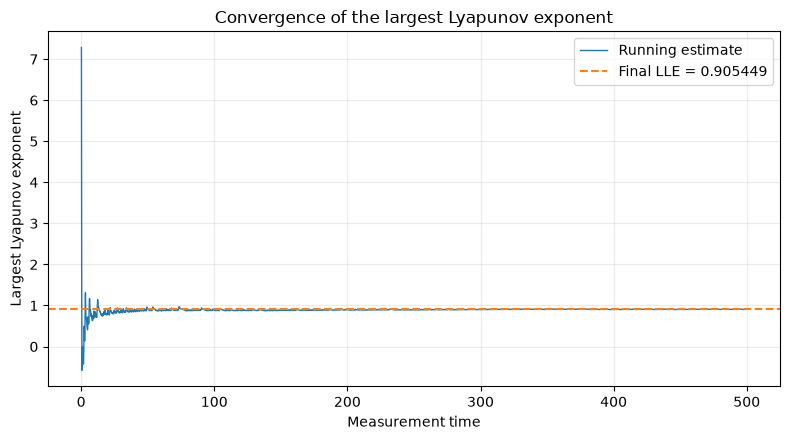

In [73]:
lle_result = largest_lyapunov_current_run(
    transient=100.0,
    tangent_warmup=10.0,
    measurement_time=500.0,
    renormalization_time=0.2,
    plot=True,
)